In [ ]:
##### 2nd Order ODE ####

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [158]:
print("Welcome to 2nd order ODE solver [mx''+cx'+kx=f(t)], by using generalized alpha method, please specify your values!")
x0=float(input("Enter your initial value x0:"))  #displacment
d_x0=float(input("Enter your initial differential value diff_x0:"))  #velocity
m=float(input("Enter your mass:"))
c=float(input("Enter your dampening constant:"))
k=float(input("Enter your spring constant:"))
alpha=float(input("Enter your learning rate/alpha:"))  #learning rate
delta_t=float(input("Enter your time step:"))
t0=float(input("Enter your initial time:"))
tf=float(input("Enter your final time:")) 

Welcome to 2nd order ODE solver [mx''+cx'+kx=f(t)], by using generalized alpha method, please specify your values!


Enter your initial value x0: 1
Enter your initial differential value diff_x0: 0
Enter your mass: 10
Enter your dampening constant: 15
Enter your spring constant: 12
Enter your learning rate/alpha: 0.5
Enter your time step: 0.1
Enter your initial time: 0
Enter your final time: 10


In [159]:
"""" NOTE!!!!- AFter entering your input values, run this part (which will return an error) then run the next part (which will also return an error)
then run this part again (which it will run successfully) and then run the next part again for graphs"""

#Numerical Solver
np.set_printoptions(legacy='1.25')

def func(t): #our forcing function to be user define
    return 0

def F1(k,m,delta_t,alpha,c):
    return ((m+c*alpha*delta_t)/(m+c*alpha*delta_t+k*(alpha*delta_t)**2))
M=F1(k,m,delta_t,alpha,c)

def F2(k,m,delta_t,alpha,c):
    return ((alpha*delta_t)/(m+c*alpha*delta_t))
N=F2(k,m,delta_t,alpha,c)

def F3(k,m,delta_t,alpha,c):
    return (((1-alpha)*delta_t)/(m+c*alpha*delta_t))
O=F3(k,m,delta_t,alpha,c)

def F4(k,m,delta_t,alpha,c,d_x0):
    return ((d_x0*m)/(m+c*alpha*delta_t))
P=F4(k,m,delta_t,alpha,c,d_x0)

def y_2(M,N,O,P,delta_t,alpha,k,c,d_x0,x0,t):  #I am going insane
    T1=func(t+delta_t)
    T2=func(t)

    d_x=(M*((N*(T1-k*(1-alpha)*delta_t*d_x0+x0))+(O*(T2-c*d_x0-k*x))+P))
    return d_x
    
d_x=y_2(M,N,O,P,delta_t,alpha,k,c,d_x0,x0,t) #callin back is important

def y_1(alpha,delta_t,d_x,d_x0,x0):

    x=((alpha*delta_t*d_x)+((1-alpha)*delta_t*d_x0)+(x0))
    return x

x=y_1(alpha,delta_t,d_x,d_x0,x0)

In [1]:
# loops
np.set_printoptions(legacy='1.25')
#initial values
t=t0
x=x0
d_x=d_x0

# lists to store results
t_vals1,x_vals1,dx_vals=[t1],[x],[d_x]

# loops between t0 and tf
for T in np.arange(t0,tf,delta_t):

    # computing our coefficients for each loop
    M=F1(k,m,delta_t,alpha,c)
    N=F2(k,m,delta_t,alpha,c)
    O=F3(k,m,delta_t,alpha,c)
    P=F4(k,m,delta_t,alpha,c,d_x0)

    # step updates
    d_x=y_2(M,N,O,P,delta_t,alpha,k,c,d_x0,x0,t)
    x=y_1(alpha,delta_t,d_x,d_x0,x0)

    # appending the lists
    t=t+delta_t
    t_vals1.append(t)
    x_vals1.append(x) 
    dx_vals.append(d_x)

    # new values assigned to old
    x0=x
    d_x0=d_x

print(t_vals)
print(x_vals)

plt.plot(t_vals1,x_vals1,color="blue",label="numerical",linestyle="--")
plt.grid(True)
plt.xlabel("time value")
plt.ylabel("x-value")
plt.title("Numerical x vs t graph for ODE")

NameError: name 'np' is not defined

[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999, 1.0999999999999999, 1.2, 1.3, 1.4000000000000001, 1.5000000000000002, 1.6000000000000003, 1.7000000000000004, 1.8000000000000005, 1.9000000000000006, 2.0000000000000004, 2.1000000000000005, 2.2000000000000006, 2.3000000000000007, 2.400000000000001, 2.500000000000001, 2.600000000000001, 2.700000000000001, 2.800000000000001, 2.9000000000000012, 3.0000000000000013, 3.1000000000000014, 3.2000000000000015, 3.3000000000000016, 3.4000000000000017, 3.5000000000000018, 3.600000000000002, 3.700000000000002, 3.800000000000002, 3.900000000000002, 4.000000000000002, 4.100000000000001, 4.200000000000001, 4.300000000000001, 4.4, 4.5, 4.6, 4.699999999999999, 4.799999999999999, 4.899999999999999, 4.999999999999998, 5.099999999999998, 5.1999999999999975, 5.299999999999997, 5.399999999999997, 5.4999999999999964, 5.599999999999996, 5.699999999999996, 5.799999999999995, 5.899999999999995, 5.

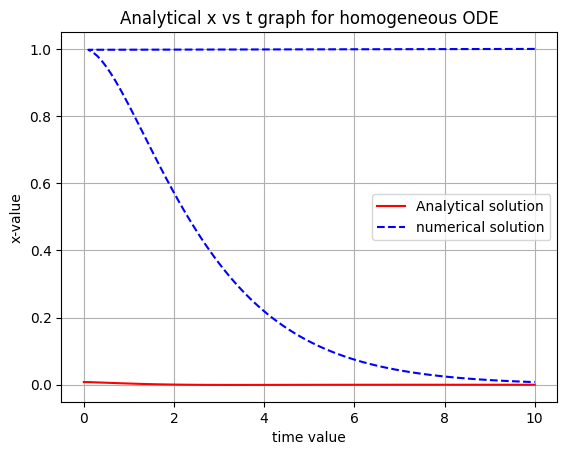

In [161]:
# Analytical solution function homogenous functions
np.set_printoptions(legacy='1.25')
# Derived parameters
Cc=2*(k*m)**0.5
psi=c/Cc
w=(k/m)**0.5

# A and B
def a(d_x0,psi,w,x0):
    return (d_x0+psi*w*x0) /(w*(1-psi**2)**0.5)
A=a(d_x0,psi,w,x0)

def b(x0):
    return x0
B=b(x0)

def analytical(t,psi,w,A,B):
    wd=w*(1-psi**2)**0.5
    return np.exp(-psi*w*t)*(A*np.sin(wd*t)+B*np.cos(wd*t))

# Initialize variables
t=t0
x=x0

# Lists to store results
t_vals=[t]
x_vals=[x]

# Loop between t0 and tf
for T in np.arange(t0,tf,delta_t):
    # compute analytical x for current time
    x = analytical(t,psi,w,A,B)

    # append to lists
    t=t+delta_t
    t_vals.append(t)
    x_vals.append(x)

# Output and plot
print(t_vals)
print(x_vals)

plt.plot(t_vals,x_vals,color="red",label="Analytical solution")
plt.plot(t_vals1,x_vals1,color="blue",label="numerical solution",linestyle="--")
plt.grid(True)
plt.xlabel("time value")
plt.ylabel("x-value")
plt.title("Analytical x vs t graph for homogeneous ODE")
plt.legend()
plt.show()

[0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009000000000000001, 0.010000000000000002, 0.011000000000000003, 0.012000000000000004, 0.013000000000000005, 0.014000000000000005, 0.015000000000000006, 0.016000000000000007, 0.017000000000000008, 0.01800000000000001, 0.01900000000000001, 0.02000000000000001, 0.02100000000000001, 0.022000000000000013, 0.023000000000000013, 0.024000000000000014, 0.025000000000000015, 0.026000000000000016, 0.027000000000000017, 0.028000000000000018, 0.02900000000000002, 0.03000000000000002, 0.03100000000000002, 0.03200000000000002, 0.03300000000000002, 0.03400000000000002, 0.035000000000000024, 0.036000000000000025, 0.037000000000000026, 0.03800000000000003, 0.03900000000000003, 0.04000000000000003, 0.04100000000000003, 0.04200000000000003, 0.04300000000000003, 0.04400000000000003, 0.04500000000000003, 0.046000000000000034, 0.047000000000000035, 0.048000000000000036, 0.04900000000000004, 0.05000000000000004, 0.05100000000000004, 0.0520000000000

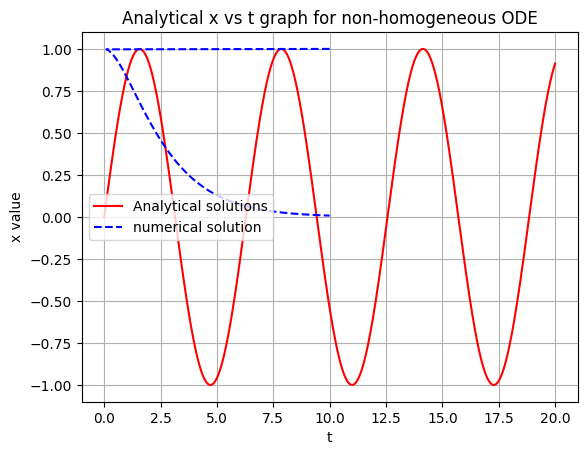

In [162]:
#For manufactured solutions for non homogeneous solutions
import numpy as np
import matplotlib.pyplot as plt

m=10   #mass
c=15   #damping
k=12   #stiffness

# analytical solution solver
def analytical_x(t):
    return np.sin(t)

# forcing function from ODE:m*x"+c*x'+k*x=f(t)
def func(t):
    return m*(-np.sin(t))+c*np.cos(t)+k*np.sin(t)

# time setup
t0=0
tf=20
delta_t=0.001
t=t0

# lists to store results
t_vals=[t]
x_vals=[analytical_x(t)]
f_vals=[forcing(t)]

# while loop to calculate the values
while t<tf:
    t=t+delta_t
    x=analytical_x(t)
    t_vals.append(t)
    x_vals.append(x)
    f_vals.append(func(t))

print(t_vals)
print(x_vals)

plt.plot(t_vals,x_vals,color="red",label="Analytical solutions")
#plt.plot(t_vals,f_vals,color="green",label="forcing function")
plt.plot(t_vals1,x_vals1,color="blue",label="numerical solution",linestyle="--")
plt.xlabel("t")
plt.ylabel("x value")
plt.legend()
plt.title("Analytical x vs t graph for non-homogeneous ODE")
plt.grid(True)
plt.show()